# **E-Commerce Customer Analytics**
###**Exploratory Data Analysis (EDA)**

**Dataset:** UCI Online Retail Dataset  
**Notebook:** 01 of 06  
**Goal:** Understand the structure, quality, and characteristics of the raw transaction data before any cleaning or modelling begins.

We are not fixing anything in this notebook. We are only looking, asking questions, and documenting what we find.

**Import Libraries**

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings("ignore")

os.makedirs("/content/outputs/charts", exist_ok=True)

**Load the Dataset**

In [44]:
df = pd.read_excel("/content/Online Retail.xlsx")

In [45]:
print(f"Rows : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")
print(f"Columns names: {list(df.columns)}")

Rows : 541909
Columns : 8
Columns names: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


In [46]:
# First look at the data
df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom


In [47]:
# Data structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


**Date Range**

Understanding the time span of the dataset tells us how many months of data we have, which directly affects how we define churn windows and build retention cohorts. A longer date range gives us more reliable cohort analysis.

In [48]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

date_min = df["InvoiceDate"].min()
date_max = df["InvoiceDate"].max()
date_range = (date_max - date_min).days

print(f"Earliest transaction : {date_min.date()}")
print(f"Latest transaction : {date_max.date()}")
print(f"Date Range: {date_range} days ({date_range // 30} months approx.)")

Earliest transaction : 2010-12-01
Latest transaction : 2011-12-09
Date Range: 373 days (12 months approx.)


In [49]:
# Unique value count
unique_summary = {
    "Unique Customers" : df["CustomerID"].nunique(),
    "Unique Invoices" : df["InvoiceDate"].nunique(),
    "Unique Products" : df["StockCode"].nunique(),
    "Unique Countries" : df["Country"].nunique(),
}

for key, val in unique_summary.items():
    print(f"{key}: {val}")

Unique Customers: 4372
Unique Invoices: 23260
Unique Products: 4070
Unique Countries: 38


**Country Distribution**

The dataset is international, but heavily skewed toward the United Kingdom. For our client sample, we will likely filter to UK-only during cleaning to ensure the customer behaviour patterns we model are consistent and not influenced by cross-country variation.

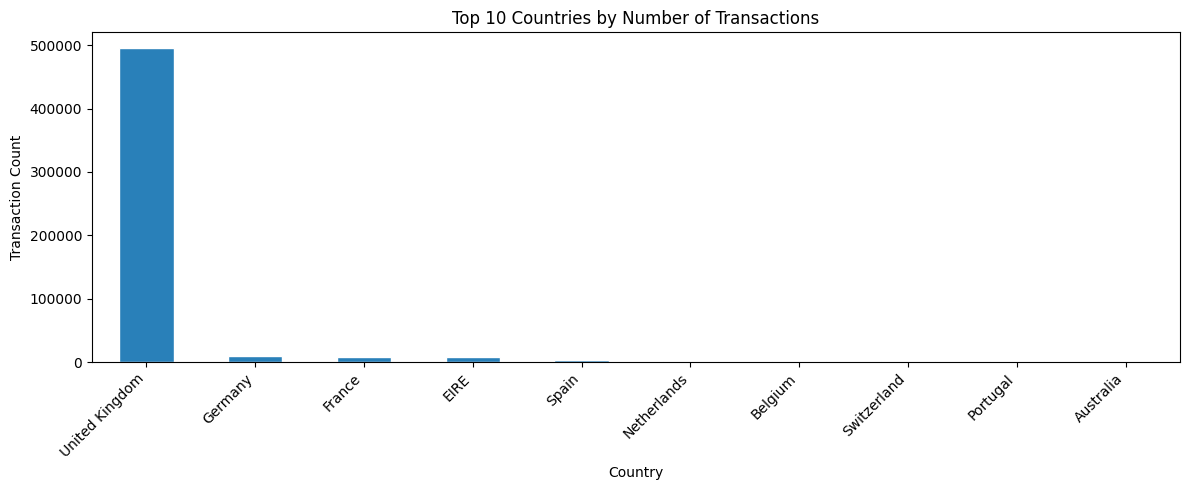

In [50]:
top_countries = df["Country"].value_counts().head(10)

fig, ax = plt.subplots(figsize=(12,5))
top_countries.plot(kind="bar", ax=ax, color="#2980b9", edgecolor="white")
ax.set_title("Top 10 Countries by Number of Transactions")
ax.set_ylabel("Transaction Count")
ax.set_xlabel("Country")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.savefig("/content/outputs/charts/01_top_countries.png")
plt.show()

In [51]:
uk_pct = (df[df["Country"] == "United Kingdom"].shape[0] / len(df)) * 100
print(f"UK transctions make up {uk_pct:.1f}% of the entire dataset.")

UK transctions make up 91.4% of the entire dataset.


**Cancelled Orders (Invoices Starting With 'C')**


Cancellations are embedded in the dataset as negative quantity rows, with invoice numbers prefixed by the letter `C`. These are not real purchases and must be identified now and removed in the cleaning stage. We document their volume here.

In [52]:
cancelled = df[df["InvoiceNo"].astype(str).str.startswith("C")]
print(f"Cancelled transactions : {len(cancelled)}")
print(f"% of cancelled transactions : {(len(cancelled) / len(df)) * 100:.2f}%")

Cancelled transactions : 9288
% of cancelled transactions : 1.71%


**Quantity and Unit Price Distribution**

We check for anomalies in the two numeric columns we will use to calculate revenue. Negative values in `Quantity` indicate returns or cancellations. Zero or negative `UnitPrice` values need to be flagged.

In [53]:
# Quantity
print(df["Quantity"].describe())
print(f"\nNegative quantity rows : {(df["Quantity"] < 0).sum()}")
print(f"Zero quantity rows : {(df["Quantity"] == 0).sum()}")

count    541909.000000
mean          9.552250
std         218.081158
min      -80995.000000
25%           1.000000
50%           3.000000
75%          10.000000
max       80995.000000
Name: Quantity, dtype: float64

Negative quantity rows : 10624
Zero quantity rows : 0


In [54]:
# UnitPrice
print(df["UnitPrice"].describe())
print(f"\nNegative price rows : {(df["UnitPrice"] < 0).sum()}")
print(f"Zero price rows : {(df["UnitPrice"] == 0).sum()}")

count    541909.000000
mean          4.611114
std          96.759853
min      -11062.060000
25%           1.250000
50%           2.080000
75%           4.130000
max       38970.000000
Name: UnitPrice, dtype: float64

Negative price rows : 2
Zero price rows : 2515


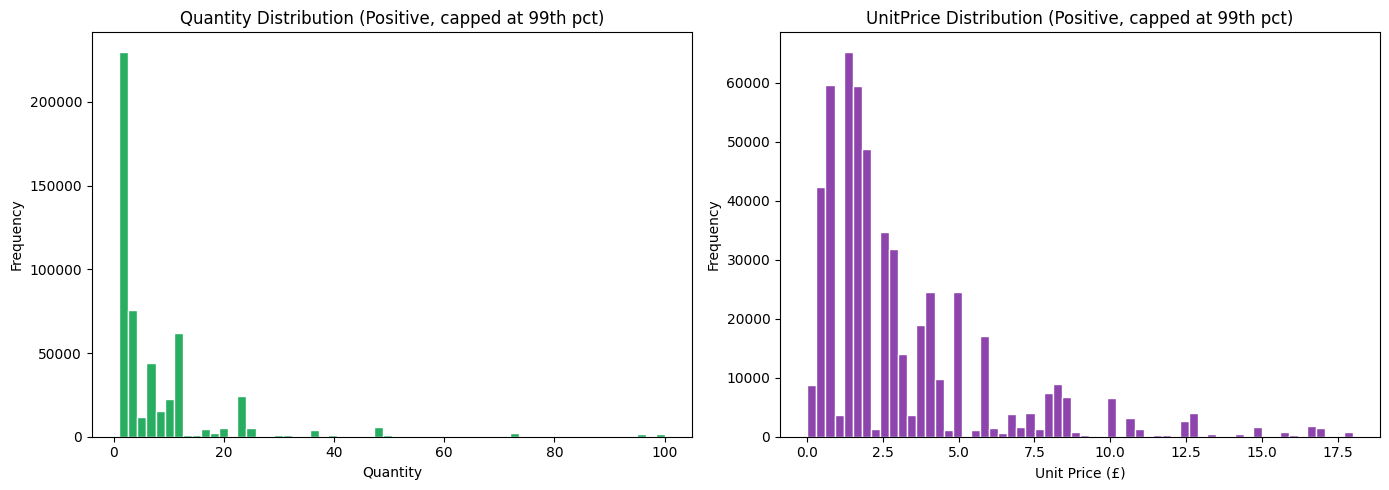

Chart saved.


In [55]:
# Both quantity and UnitPrice cap at 99th percentile for readability
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Quantity
q99 = df["Quantity"].quantile(0.99)
df[df["Quantity"].between(1, q99)]["Quantity"].plot(
    kind="hist", bins=60, ax=axes[0], color="#27ae60", edgecolor="white"
)
axes[0].set_title("Quantity Distribution (Positive, capped at 99th pct)")
axes[0].set_xlabel("Quantity")
axes[0].set_ylabel("Frequency")

# UnitPrice
p99 = df["UnitPrice"].quantile(0.99)
df[df["UnitPrice"].between(0.01, p99)]["UnitPrice"].plot(
    kind="hist", bins=60, ax=axes[1], color="#8e44ad", edgecolor="white"
)
axes[1].set_title("UnitPrice Distribution (Positive, capped at 99th pct)")
axes[1].set_xlabel("Unit Price (£)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.savefig("/content/outputs/charts/03_quantity_price_distributions.png", dpi=150)
plt.show()
print("Chart saved.")

**Monthly Transaction Volume**

We plot the number of transactions per month to understand seasonality and whether the data has any unusual spikes or dead periods. This also confirms whether the dataset covers enough months to build meaningful retention cohorts.

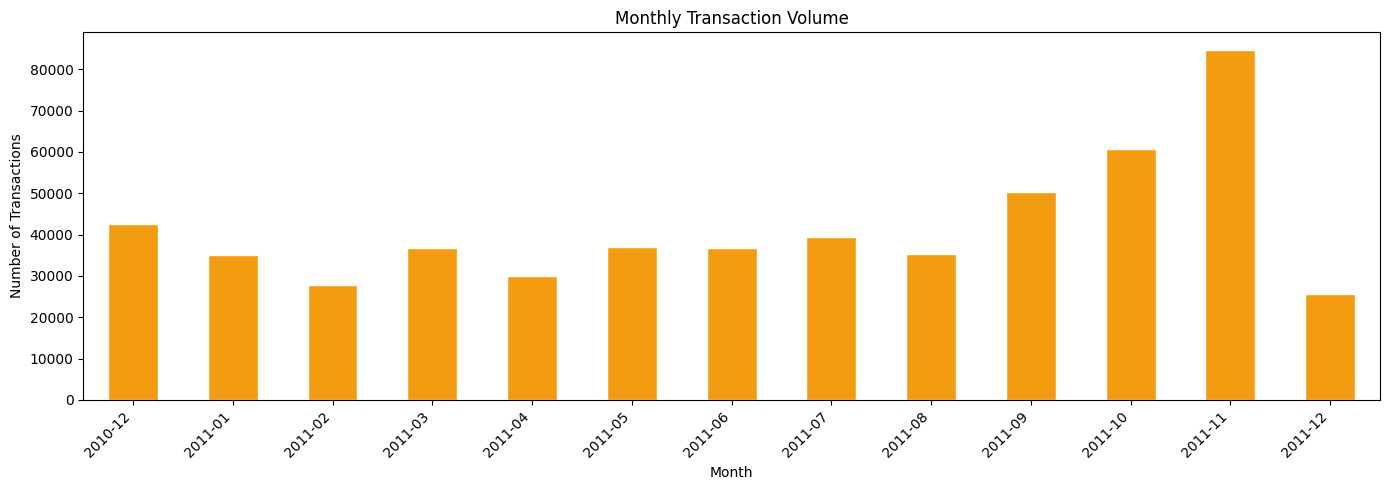

In [56]:
df["YearMonth"] = df["InvoiceDate"].dt.to_period("M")
monthly_transactions = df.groupby("YearMonth").size()

fig, ax = plt.subplots(figsize=(14, 5))
monthly_transactions.plot(kind="bar", ax=ax, color="#f39c12", edgecolor="white")
ax.set_title("Monthly Transaction Volume")
ax.set_ylabel("Number of Transactions")
ax.set_xlabel("Month")
ax.set_xticklabels(
    [str(p) for p in monthly_transactions.index], rotation=45, ha="right"
)

plt.tight_layout()
plt.savefig("/content/outputs/charts/04_monthly_transaction_volume.png", dpi=150)
plt.show()

**Top Products by Transaction Frequency**

We identify the most frequently purchased products. While this won't feed directly into our churn or LTV models, it gives context about the type of goods being sold.

In [57]:
top_products = (
    df[df["Description"].notna()]
    .groupby("Description")["InvoiceNo"]
    .count()
    .sort_values(ascending=False)
    .head(10)
)
top_products.head()

,InvoiceNo
Description,
WHITE HANGING HEART T-LIGHT HOLDER,2369
REGENCY CAKESTAND 3 TIER,2200
JUMBO BAG RED RETROSPOT,2159
PARTY BUNTING,1727
LUNCH BAG RED RETROSPOT,1638


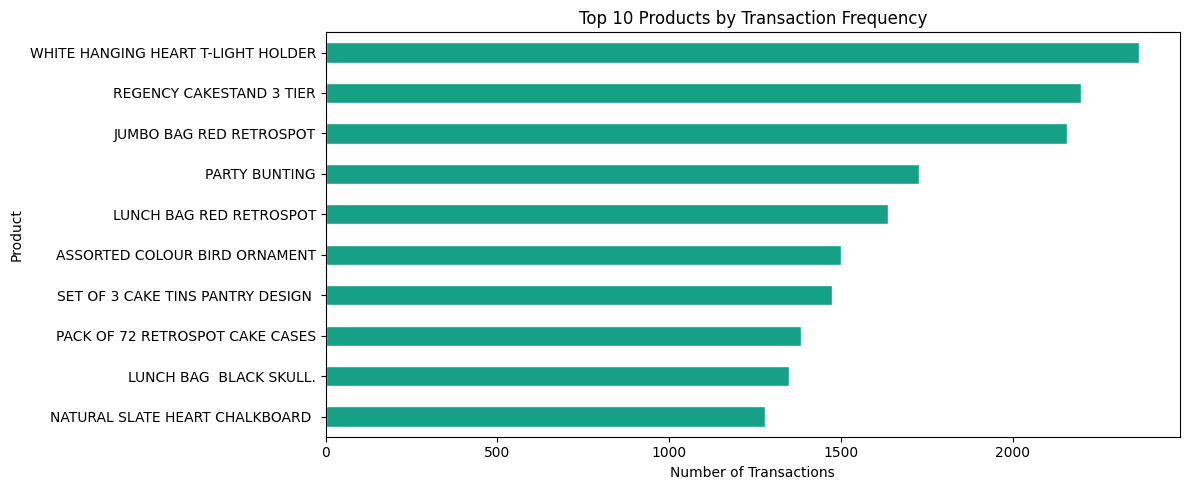

In [58]:
fig, ax = plt.subplots(figsize=(12, 5))
top_products.plot(kind="barh", ax=ax, color="#16a085", edgecolor="white")
ax.set_title("Top 10 Products by Transaction Frequency")
ax.set_xlabel("Number of Transactions")
ax.set_ylabel("Product")
ax.invert_yaxis()

plt.tight_layout()
plt.savefig("/content/outputs/charts/05_top_products.png", dpi=150)
plt.show()

## **EDA Results**

**The dataset has 541,909 rows and 8 columns.**
The columns are: `InvoiceNo`, `StockCode`, `Description`, `Quantity`, `InvoiceDate`, `UnitPrice`, `CustomerID`, and `Country`.

---

### **Missing Values**

Two columns have missing data:

- `Description` is missing 1,454 rows — minor, not a big deal since we don't use it for modelling
- `CustomerID` is missing **135,080 rows** — that's about 25% of the entire dataset gone. Every row without a CustomerID is useless to us because we can't tie a transaction to a person. These get dropped in cleaning, no negotiation.

---

### **Date Range**

The data runs from **1st December 2010 to 9th December 2011** — just over 12 months. That's enough. We can build meaningful cohorts from this and the churn window (90 days) fits comfortably within the range.

---

### **Scale of the Data**

- 4,372 unique customers
- 25,900 unique invoices
- 4,070 unique products
- 38 countries

The customer count dropping to 4,372 already hints at the missing CustomerID problem — the real number before dropping nulls would be higher.

---

### **Country Breakdown**

UK transactions make up **91.4% of the dataset.** We're filtering to UK only in cleaning. Mixing purchasing behaviour across 38 countries into one model doesn't make sense — different price points, currencies, and buying patterns would distort everything.

---

### **Cancelled Orders**

9,288 cancelled transactions, making up **1.71% of the data.** Small percentage but they carry negative quantities, which would corrupt any revenue or LTV calculation. They go.

---

### **Quantity Issues**

The `Quantity` column has a min of **-80,995** and a max of 80,995. That's not a typo — some of those negative values are tied to the cancellations we already flagged, but not all of them. There are **10,624 negative quantity rows** in total, which is more than the 9,288 cancellations. That means some negatives exist outside of cancelled invoices too — likely returns or data entry errors. All of them get removed.

No zero quantity rows, which is one less thing to worry about.

---

### **UnitPrice Issues**

- **2 negative price rows** — meaningless, dropping them
- **2,515 zero price rows** — this is more interesting. Zero price usually means internal stock transfers, samples, or write-offs. None of these are real customer purchases so they go too.

The max unit price is £38,970 which is extreme, but we'll handle outliers in the feature engineering stage, not cleaning.

---

### **What This Means Going Into Cleaning**

| What We Found | What We Do About It |
|---|---|
| 135,080 rows missing CustomerID | Drop them |
| 9,288 cancelled invoices (prefix 'C') | Drop them |
| 10,624 negative quantity rows | Drop them |
| 2,515 zero UnitPrice rows | Drop them |
| 2 negative UnitPrice rows | Drop them |
| 38 countries, 91.4% UK | Filter to UK only |
| No TotalPrice column | Create it: Quantity × UnitPrice |